C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\2038040173.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df_data['f'].max()))


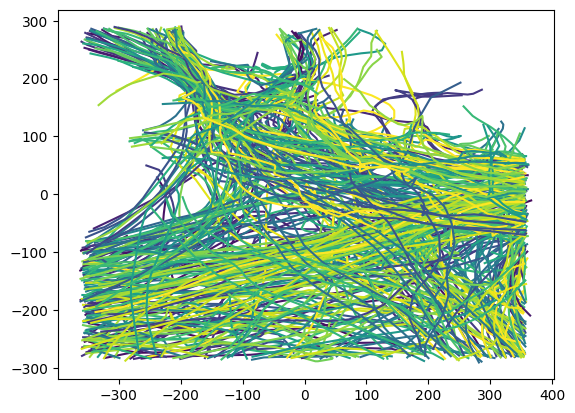

In [9]:
import pandas as pd
from pathlib import Path
from io import StringIO
from src.dataset.base_dataset import BaseDataset


data_path = r'./data\UCY\data\data_university_students\students001.vsp'

data_path = Path(data_path)
if not data_path.exists():
    raise FileNotFoundError(f"Data path {data_path} not found.")

name = (
    data_path.parent.name.removeprefix("data_")
    + "-"
    + data_path.name.removesuffix(".vsp")
)

df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_data = pd.concat(df_list, ignore_index=True)
df_data = df_data[['f', 'id', 'x', 'y', 'type']]

df_data_list = []
for id, group in df_data.groupby('id'):
    if group['type'].nunique() > 1:
        raise ValueError(f"ID {id} has multiple types: {group['type'].unique()}")
    new_group = BaseDataset.resample_dataframe(group, raw_fps=30, target_fps=2.5)
    new_group['id'] = id
    new_group['type'] = group['type'].iloc[0]
    df_data_list.append(new_group)
df_data = pd.concat(df_data_list, ignore_index=True)

import matplotlib.pyplot as plt
for id, group in df_data.groupby('id'):
    plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df_data['f'].max()))

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\3256452156.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df_data['f'].max()))


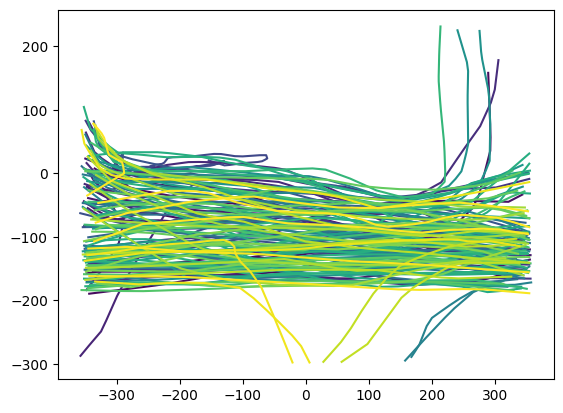

In [10]:
import pandas as pd
from pathlib import Path
from io import StringIO
from src.dataset.base_dataset import BaseDataset


data_path = r'./data\UCY\data\data_zara\crowds_zara01.vsp'

data_path = Path(data_path)
if not data_path.exists():
    raise FileNotFoundError(f"Data path {data_path} not found.")

name = (
    data_path.parent.name.removeprefix("data_")
    + "-"
    + data_path.name.removesuffix(".vsp")
)

df_list = []
with open(data_path, 'r') as f:
    P = int(f.readline().split(' ')[0])  # 行人数
    for p in range(P):
        S = int(f.readline().split(' ')[0])  # 控制柄数
        csv = [f.readline().removesuffix(' - (2D point, m_id)') for _ in range(S)]
        df = pd.read_csv(
            StringIO('\n'.join(csv)),
            sep=" ",
            nrows=S,
            usecols=[0, 1, 2, 3],
            names=["x", "y", "f", "direction"],
        )
        df["id"] = p
        df['type'] = 'pedestrian'
        df_list.append(df)
df_data = pd.concat(df_list, ignore_index=True)
df_data = df_data[['f', 'id', 'x', 'y', 'type']]

df_data_list = []
for id, group in df_data.groupby('id'):
    if group['type'].nunique() > 1:
        raise ValueError(f"ID {id} has multiple types: {group['type'].unique()}")
    new_group = BaseDataset.resample_dataframe(group, raw_fps=30, target_fps=2.5)
    new_group['id'] = id
    new_group['type'] = group['type'].iloc[0]
    df_data_list.append(new_group)
df_data = pd.concat(df_data_list, ignore_index=True)

import matplotlib.pyplot as plt
for id, group in df_data.groupby('id'):
    plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df_data['f'].max()))

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\3917135754.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))


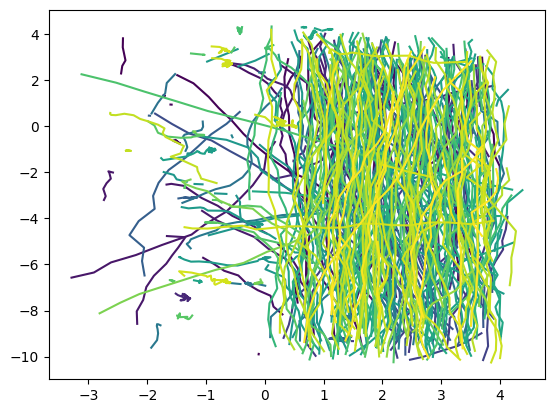

In [68]:
import pandas as pd

df = pd.read_csv(
    'data/ETH/seq_hotel/obsmat.txt',
    sep=' ',
    names=['f', 'id', 'x', 'z', 'y', 'vx', 'vz', 'vy'],
    usecols=['f', 'id', 'x', 'y'],
    skipinitialspace=True,
)

import matplotlib.pyplot as plt
for id, group in df.groupby('id'):
    plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\1995626700.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))


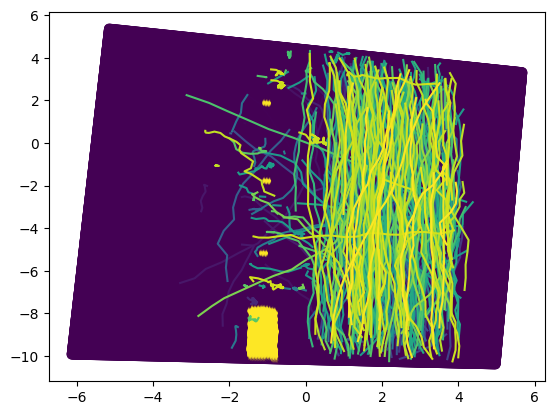

In [72]:
import torch
import numpy as np
from PIL import Image

H = np.loadtxt('data/ETH/seq_hotel/H.txt')
image = Image.open('data/ETH/seq_hotel/map.png')
array = np.array(image)

H = torch.tensor(H, dtype=torch.float32)  # (3, 3)
# image_coord = torch.tensor(array, dtype=torch.float32)  # (2,)

ii = torch.arange(array.shape[0])
jj = torch.arange(array.shape[1])
ii,jj = torch.meshgrid(ii, jj, indexing='ij')
image_coord = torch.stack([ii, jj], dim=-1).float()  # (H, W, 2)

"""
Give a tensor shaped like [N, (M,) 2], calculate Affine Transformation
        |x|         |X|
    a * |y| = [H] * |Y|
        |1|         |1|
and return a tensor shaped like [N, (M,) 2], where a is a arbitrary real number, existing to make the last component has value 1.
"""
tmp = torch.einsum('ij, ...j->...i', H[:, :2], image_coord) + H[:, 2]  # (N, (M,) 3)
a = tmp[..., (2,)]  # (N, (M,) 3)
world_coord = tmp[..., :2] / a  # (N, (M,) 3)

plt.scatter(world_coord[..., 0].flatten(), world_coord[..., 1].flatten(), c=array.flatten())

import pandas as pd

df = pd.read_csv(
    'data/ETH/seq_hotel/obsmat.txt',
    sep=' ',
    names=['f', 'id', 'x', 'z', 'y', 'vx', 'vz', 'vy'],
    usecols=['f', 'id', 'x', 'y'],
    skipinitialspace=True,
)

for id, group in df.groupby('id'):
    plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\2780529717.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.plot(group['image_x'], group['image_y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))


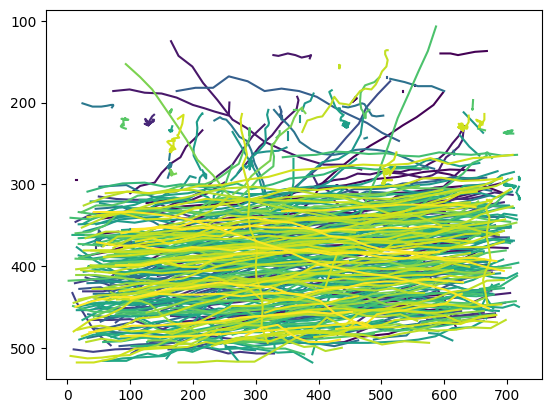

In [55]:
H = np.loadtxt('data/ETH/seq_hotel/H.txt')
H = torch.tensor(H, dtype=torch.float32)  # (3, 3)
world_coord = torch.tensor(df[['x', 'y']].values, dtype=torch.float32)  # (N, 2)
Hinv = torch.inverse(H)
tmp = torch.einsum('ij, ...j->...i', Hinv[:, :2], world_coord) + Hinv[:, 2]  # (N, (M,) 3)
a = tmp[..., (2,)]  # (N, (M,) 3)
image_coord = tmp[..., :2] / a  # (N, (M,) 3)

df['image_y'] = image_coord[:, 0].numpy()
df['image_x'] = image_coord[:, 1].numpy()

import matplotlib.pyplot as plt
for id, group in df.groupby('id'):
    plt.plot(group['image_x'], group['image_y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))
plt.gca().yaxis.set_inverted(True)

In [31]:
((df['x'].diff() ** 2 + df['y'].diff() ** 2)**0.5).mean()

np.float64(3.8036067105240825)

In [ ]:
import torch
import numpy as np
from PIL import Image

H = np.loadtxt('data/ETH/seq_hotel/H.txt')
image = Image.open('data/ETH/seq_hotel/map.png')
array = np.array(image)

H = torch.tensor(H, dtype=torch.float32)  # (3, 3)
# image_coord = torch.tensor(array, dtype=torch.float32)  # (2,)

ii = torch.arange(array.shape[0])
jj = torch.arange(array.shape[1])
ii,jj = torch.meshgrid(ii, jj, indexing='ij')
image_coord = torch.stack([ii, jj], dim=-1).float()  # (H, W, 2)

"""
Give a tensor shaped like [N, (M,) 2], calculate Affine Transformation
        |x|         |X|
    a * |y| = [H] * |Y|
        |1|         |1|
and return a tensor shaped like [N, (M,) 2], where a is a arbitrary real number, existing to make the last component has value 1.
"""
tmp = torch.einsum('ij, ...j->...i', H[:, :2], image_coord) + H[:, 2]  # (N, (M,) 3)
a = tmp[..., (2,)]  # (N, (M,) 3)
world_coord = tmp[..., :2] / a  # (N, (M,) 3)

plt.scatter(world_coord[..., 0].flatten(), world_coord[..., 1].flatten(), c=array.flatten())

import pandas as pd

df = pd.read_csv(
    'data/ETH/seq_hotel/obsmat.txt',
    sep=' ',
    names=['f', 'id', 'x', 'z', 'y', 'vx', 'vz', 'vy'],
    usecols=['f', 'id', 'x', 'y'],
    skipinitialspace=True,
)

for id, group in df.groupby('id'):
    plt.plot(group['x'], group['y'], c=plt.cm.get_cmap('viridis')(group['f'].max() / df['f'].max()))

In [79]:
array.shape

(576, 720)

C:\Users\YuMeow\AppData\Local\Temp\ipykernel_53468\2550468034.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


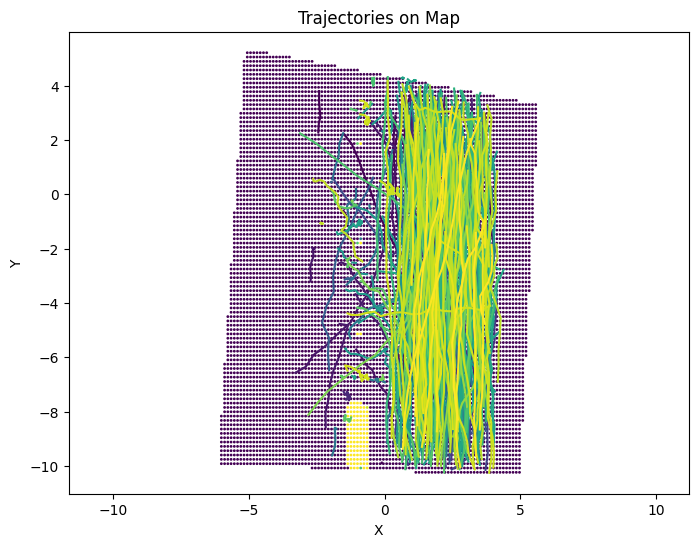

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

# === 1. 读取单应性矩阵和地图图像 ===
H = np.loadtxt('data/ETH/seq_hotel/H.txt')  # 形状 (3, 3)
image = Image.open('data/ETH/seq_hotel/map.png')
array = np.array(image)

# === 2. 构造像素坐标网格 ===
h, w = array.shape[:2]
ii, jj = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
image_coord = np.stack([ii, jj], axis=-1).astype(np.float32)  # (H, W, 2)

# === 3. 应用单应性变换（齐次坐标变换）===
# [Xw, Yw, W] = H * [x, y, 1]
xy1 = np.concatenate([image_coord, np.ones((*image_coord.shape[:2], 1), dtype=np.float32)], axis=-1)  # (H, W, 3)
tmp = xy1 @ H.T  # (H, W, 3)
world_coord = tmp[..., :2] / tmp[..., 2:3]  # 除以最后一维以归一化 (H, W, 2)

df_map = pd.DataFrame(world_coord.reshape(-1, 2), columns=['x', 'y'])
df_map['value'] = array.reshape(-1)

# 提取数据
x = df_map['x'].values
y = df_map['y'].values
v = df_map['value'].values

from scipy.interpolate import griddata
# 生成网格
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 100),
    np.linspace(ymin, ymax, 100)
)

# 进行双线性插值（method='linear'）
zz = griddata(
    points=df_map[['x', 'y']].values,
    values=v,
    xi=(xx, yy),
    method='linear'  # 'linear' 对应双线性插值
)
x = xx.reshape(-1)
y = yy.reshape(-1)
v = zz.reshape(-1)


# === 4. 绘制坐标变换后的地图点 ===
plt.figure(figsize=(8, 6))
plt.scatter(x, y, c=v, s=1)
plt.axis('equal')
plt.title('World coordinates (from map)')
plt.xlabel('X')
plt.ylabel('Y')

# === 5. 读取轨迹数据 ===
df = pd.read_csv(
    'data/ETH/seq_hotel/obsmat.txt',
    sep=' ',
    names=['f', 'id', 'x', 'z', 'y', 'vx', 'vz', 'vy'],
    usecols=['f', 'id', 'x', 'y'],
    skipinitialspace=True,
)

# === 6. 按 ID 绘制轨迹 ===
cmap = plt.cm.get_cmap('viridis')
for pid, group in df.groupby('id'):
    plt.plot(group['x'], group['y'], color=cmap(group['f'].max() / df['f'].max()))

plt.title('Trajectories on Map')
plt.show()